# Realized Volatility Forecasting with XGBoost

This notebook implements the XGBoost robustness-check stage of the project.
It loads precomputed outputs from the GSADF and GARCH notebooks to avoid
duplicating work, then trains an XGBoost model to forecast 4-week realized
volatility for BTC and ETH at weekly frequency.

## Repository layout
- notebook location: `notebooks/04_xgboost_vol.ipynb`
- price and volume input: `data/merged_data_v2.csv`
- precomputed model inputs: `output/models/old/`
- XGBoost figures: `output/figures/`
- XGBoost tables: `output/tables/`

## Required input files
- `data/merged_data_v2.csv`
- `output/models/old/garch_results.pkl`
- `output/models/old/bubble_dummy.pkl`
- `output/models/old/old_gsadf_results.pkl`

## Dependencies
Tested with: pandas>=1.5, numpy>=1.23, xgboost>=1.7, scikit-learn>=1.2,
             matplotlib>=3.6, seaborn>=0.12

Install: pip install pandas numpy xgboost scikit-learn matplotlib seaborn

## 0. Setup

In [1]:
import warnings
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

In [2]:
# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [3]:
def find_repo_root(start_path: Path) -> Path:
    """
    Locate the repository root by searching upward for the expected project folders.

    Parameters
    ----------
    start_path : Path
        Starting directory for the upward search.

    Returns
    -------
    Path
        Repository root containing data, notebooks, and output folders.
    """
    for candidate in [start_path, *start_path.parents]:
        if (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "output").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root. Run this notebook from within the project tree."
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
DATA_DIR = REPO_ROOT / "data"
OLD_MODEL_DIR = REPO_ROOT / "output" / "models" / "old"
FIGURES_DIR = REPO_ROOT / "output" / "figures"
TABLES_DIR = REPO_ROOT / "output" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "merged_data_v2.csv"
GSADF_RESULTS_PATH = OLD_MODEL_DIR / "old_gsadf_results.pkl"
BUBBLE_DUMMY_PATH = OLD_MODEL_DIR / "bubble_dummy.pkl"
GARCH_RESULTS_PATH = OLD_MODEL_DIR / "garch_results.pkl"

PREDICTED_VS_ACTUAL_FIG_PATH = FIGURES_DIR / "xgboost_predicted_vs_actual.png"
FEATURE_IMPORTANCE_FIG_PATH = FIGURES_DIR / "xgboost_feature_importance.png"
SUMMARY_TABLE_PATH = TABLES_DIR / "xgboost_summary_metrics.csv"
FEATURE_IMPORTANCE_TABLE_PATH = TABLES_DIR / "xgboost_feature_importance.csv"

ASSETS = {
    "BTC": {"price": "btc_adj_close", "volume": "btc_volume"},
    "ETH": {"price": "eth_adj_close", "volume": "eth_volume"},
}

TEST_SIZE = 0.20

PARAM_GRID = {
    "learning_rate": [0.03, 0.05, 0.10],
    "max_depth": [2, 3, 4],
    "n_estimators": [100, 200, 400],
}

BASE_XGB_PARAMS = {
    "objective": "reg:squarederror",
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "n_jobs": 1,   # deterministic; change locally if speed is needed
}

print("Repository root:", REPO_ROOT)
print("Data path:", DATA_PATH)
print("Old model path:", OLD_MODEL_DIR)
print("Figures path:", FIGURES_DIR)
print("Tables path:", TABLES_DIR)

Repository root: C:\Users\jayas\Downloads\EC4211 project
Data path: C:\Users\jayas\Downloads\EC4211 project\data\merged_data_v2.csv
Old model path: C:\Users\jayas\Downloads\EC4211 project\output\models\old
Figures path: C:\Users\jayas\Downloads\EC4211 project\output\figures
Tables path: C:\Users\jayas\Downloads\EC4211 project\output\tables


## 1. Weekly Price and Volume Data

In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").set_index("date")
df = df.apply(pd.to_numeric, errors="coerce")
price_df = pd.DataFrame({asset: df[cfg["price"]] for asset, cfg in ASSETS.items()})
volume_df = pd.DataFrame({asset: df[cfg["volume"]] for asset, cfg in ASSETS.items()})

# Resample to weekly (week ending Friday) to match GARCH and bubble pickle files
price_df = price_df.resample("W-FRI").last()
volume_df = volume_df.resample("W-FRI").last()
log_returns = np.log(price_df / price_df.shift(1))

display(price_df.tail())
display(volume_df.tail())

,BTC,ETH
date,,
2025-12-05,89387.757812,3024.432861
2025-12-12,90270.414062,3084.172607
2025-12-19,88103.382812,2977.970703
2025-12-26,87301.429688,2925.745605
2026-01-02,87508.828125,2967.037598


,BTC,ETH
date,,
2025-12-05,6.325640e+10,2.800027e+10
2025-12-12,8.027588e+10,2.439100e+10
2025-12-19,4.673331e+10,2.787069e+10
2025-12-26,4.245567e+10,1.856220e+10
2026-01-02,3.383021e+10,1.645189e+10


## 2. Load Precomputed Bubble Results

In [5]:
# Section 1: Load Precomputed Bubble Results
with open(GSADF_RESULTS_PATH, "rb") as f:
    gsadf_results = pickle.load(f)

with open(BUBBLE_DUMMY_PATH, "rb") as f:
    bubble_dummy = pickle.load(f)

bubble_dummy = bubble_dummy[["BTC", "ETH"]].copy()
bubble_dummy["is_bubble"] = (bubble_dummy[["BTC", "ETH"]].sum(axis=1) > 0).astype(int)

print("Bubble dummy loaded. Index:", bubble_dummy.index[0], "to", bubble_dummy.index[-1])
print(bubble_dummy[["BTC", "ETH", "is_bubble"]].sum().rename("weeks_in_bubble"))

Bubble dummy loaded. Index: 2017-11-24 00:00:00 to 2026-01-02 00:00:00
BTC          45
ETH          34
is_bubble    61
Name: weeks_in_bubble, dtype: int64


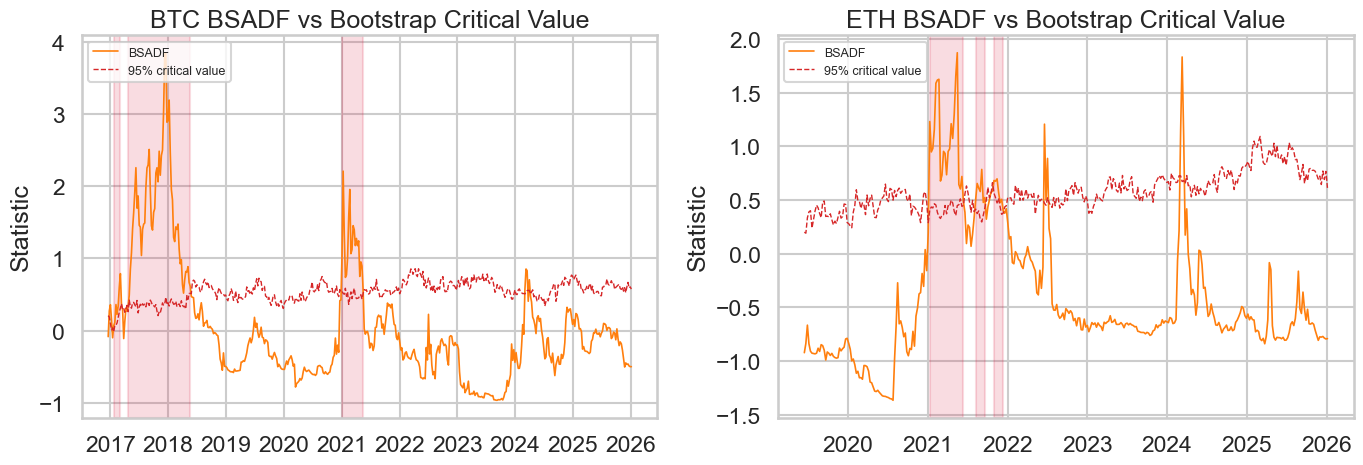

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

for ax, asset in zip(axes, ["BTC", "ETH"]):
    result = gsadf_results[asset]
    bsadf_dates = pd.to_datetime(result["bsadf_dates"])
    bsadf = np.asarray(result["bsadf"])
    cv95 = np.asarray(result["tv_cv"][0.95])

    ax.plot(bsadf_dates, bsadf, color="#ff7f0e", lw=1.2, label="BSADF")
    ax.plot(bsadf_dates, cv95, color="#d62728", ls="--", lw=1.0, label="95% critical value")
    for start_date, end_date in result["bubbles"]:
        ax.axvspan(pd.Timestamp(start_date), pd.Timestamp(end_date), color="crimson", alpha=0.15)
    ax.set_title(f"{asset} BSADF vs Bootstrap Critical Value")
    ax.set_ylabel("Statistic")
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

## 3. Load Precomputed GARCH Conditional Volatility

In [7]:
# Section 2: Load Precomputed GARCH Conditional Volatility
with open(GARCH_RESULTS_PATH, "rb") as f:
    garch_vol_raw = pickle.load(f)

# Keep BTC and ETH only; convert from percentage to return scale
garch_vol = garch_vol_raw[["BTC", "ETH"]] / 100.0

print("GARCH vol loaded. Index:", garch_vol.index[0], "to", garch_vol.index[-1])
print(garch_vol.describe().round(6))

GARCH vol loaded. Index: 2017-11-24 00:00:00 to 2026-01-02 00:00:00
              BTC         ETH
count  424.000000  424.000000
mean     0.091659    0.112526
std      0.026501    0.025049
min      0.057303    0.077951
25%      0.071204    0.093094
50%      0.087091    0.112566
75%      0.104763    0.122667
max      0.186287    0.188630


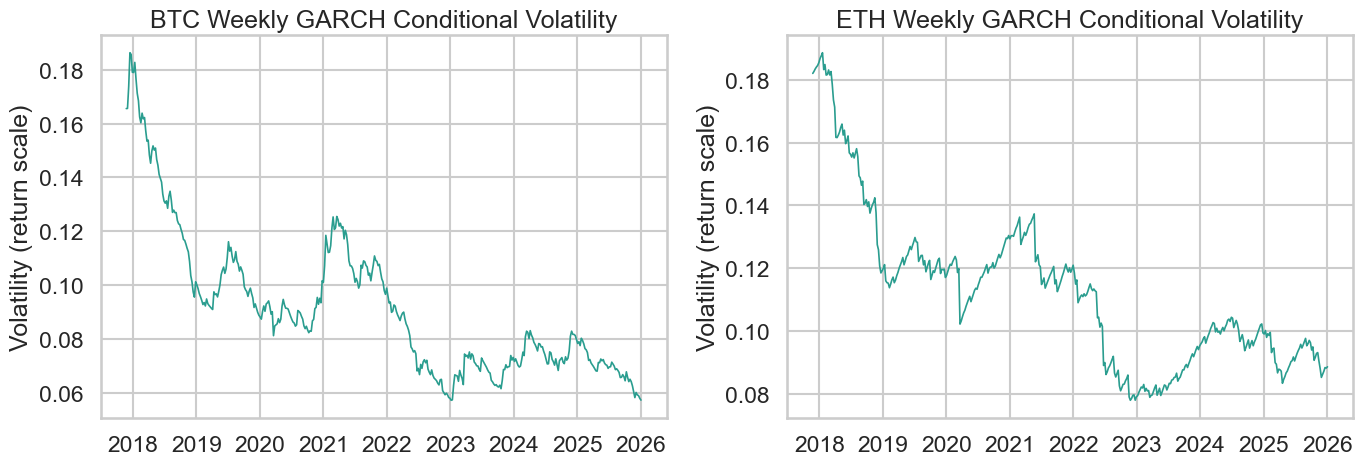

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, asset in zip(axes, ["BTC", "ETH"]):
    ax.plot(garch_vol.index, garch_vol[asset], color="#2a9d8f", lw=1.2)
    ax.set_title(f"{asset} Weekly GARCH Conditional Volatility")
    ax.set_ylabel("Volatility (return scale)")

plt.tight_layout()
plt.show()

## 4. Supervised Learning Setup and XGBoost Estimation

### Helper: RMSE scorer

In [9]:
def rmse(y_true, y_pred):
    """
    Compute root mean squared error.

    Parameters
    ----------
    y_true : array-like
        Observed target values.
    y_pred : array-like
        Predicted target values.

    Returns
    -------
    float
        Root mean squared error.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


rmse_scorer = make_scorer(rmse, greater_is_better=False)

### Feature matrix construction

In [10]:
def build_asset_frame(asset_name):
    """
    Build the weekly feature matrix for XGBoost forecasting.

    Parameters
    ----------
    asset_name : str
        One of "BTC" or "ETH".

    Returns
    -------
    pd.DataFrame
        Weekly DataFrame with columns:
        realized_vol_4wk, lag_log_return, lag_volume, lag_garch_vol, is_bubble.
    """
    frame = pd.DataFrame(index=log_returns.index)

    # Target: 4-week rolling realized volatility (weekly equivalent of 21-day)
    frame["realized_vol_4wk"] = log_returns[asset_name].rolling(4).std()

    # Features ? all lagged by 1 week to prevent look-ahead contamination
    frame["lag_log_return"] = log_returns[asset_name].shift(1)
    frame["lag_volume"] = volume_df[asset_name].shift(1)
    frame["lag_garch_vol"] = garch_vol[asset_name].shift(1)   # from garch_results.pkl / 100
    frame["is_bubble"] = bubble_dummy["is_bubble"]            # from bubble_dummy.pkl

    frame = frame.replace([np.inf, -np.inf], np.nan).dropna()
    return frame

### Model tuning and evaluation

In [11]:
def tune_and_evaluate_asset(asset_name):
    """
    Tune an XGBoost regressor and evaluate it on a chronological holdout set.

    Parameters
    ----------
    asset_name : str
        One of "BTC" or "ETH".

    Returns
    -------
    dict
        Model artifacts, metrics, CV results, test predictions, and feature importance.
    """
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    frame = build_asset_frame(asset_name)
    feature_cols = ["lag_log_return", "lag_volume", "lag_garch_vol", "is_bubble"]

    # Deterministic chronological split: no shuffled indices or random sampling.
    split_point = int(len(frame) * (1 - TEST_SIZE))
    train = frame.iloc[:split_point].copy()
    test = frame.iloc[split_point:].copy()

    X_train = train[feature_cols]
    y_train = train["realized_vol_4wk"]
    X_test = test[feature_cols]
    y_test = test["realized_vol_4wk"]

    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    estimator = XGBRegressor(
        **BASE_XGB_PARAMS,
        random_state=42,
    )

    # TimeSeriesSplit is deterministic because it creates sequential, non-shuffled folds.
    tscv = TimeSeriesSplit(n_splits=5)
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=PARAM_GRID,
        scoring={"rmse": rmse_scorer, "r2": "r2"},
        refit="rmse",
        cv=tscv,
        # Slower than parallel search, but avoids nondeterministic asynchronous scheduling
        # differences across CPU architectures and BLAS/OpenMP runtimes.
        n_jobs=1,
        verbose=0,
        return_train_score=False,
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    test_pred = pd.Series(best_model.predict(X_test), index=X_test.index, name="predicted")
    test_rmse = rmse(y_test, test_pred)
    metrics = {
        "asset": asset_name,
        "train_start": train.index.min(),
        "train_end": train.index.max(),
        "test_start": test.index.min(),
        "test_end": test.index.max(),
        "rmse": test_rmse,
        "r2": r2_score(y_test, test_pred),
        **grid.best_params_,
    }

    cv_results = pd.DataFrame(grid.cv_results_)[[
        "param_learning_rate",
        "param_max_depth",
        "param_n_estimators",
        "mean_test_rmse",
        "mean_test_r2",
        "rank_test_rmse",
    ]].sort_values("rank_test_rmse")
    cv_results["mean_test_rmse"] = -cv_results["mean_test_rmse"]

    importance = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

    print(f"{asset_name} best_params={grid.best_params_} | RMSE={test_rmse:.6f}")

    return {
        "frame": frame,
        "train": train,
        "test": test,
        "feature_cols": feature_cols,
        "best_model": best_model,
        "best_params": grid.best_params_,
        "metrics": metrics,
        "cv_results": cv_results,
        "test_predictions": pd.DataFrame({"actual": y_test, "predicted": test_pred}),
        "feature_importance": importance,
    }

In [12]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

model_results = {asset: tune_and_evaluate_asset(asset) for asset in ASSETS}
summary_df = pd.DataFrame([model_results[asset]["metrics"] for asset in ASSETS]).sort_values("asset")
display(summary_df)
summary_df.to_csv(SUMMARY_TABLE_PATH, index=False)

for asset in ASSETS:
    print(f"\nTop CV results for {asset}")
    display(model_results[asset]["cv_results"].head(5))
    model_results[asset]["cv_results"].to_csv(
        TABLES_DIR / f"xgboost_cv_results_{asset.lower()}.csv",
        index=False,
    )

print("Saved summary table to:", SUMMARY_TABLE_PATH)

BTC best_params={'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100} | RMSE=0.050834


ETH best_params={'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100} | RMSE=0.043793


,asset,train_start,train_end,test_start,test_end,rmse,r2,learning_rate,max_depth,n_estimators
0,BTC,2017-12-01,2024-05-17,2024-05-24,2026-01-02,0.050834,-3.627601,0.03,2,100
1,ETH,2017-12-08,2024-05-17,2024-05-24,2026-01-02,0.043793,-1.852828,0.03,2,100



Top CV results for BTC


,param_learning_rate,param_max_depth,param_n_estimators,mean_test_rmse,mean_test_r2,rank_test_rmse
0,0.03,2,100,0.049053,-0.458923,1
9,0.05,2,100,0.051556,-0.603022,2
1,0.03,2,200,0.052322,-0.653342,3
3,0.03,3,100,0.052467,-0.751424,4
10,0.05,2,200,0.054966,-0.800827,5



Top CV results for ETH


,param_learning_rate,param_max_depth,param_n_estimators,mean_test_rmse,mean_test_r2,rank_test_rmse
0,0.03,2,100,0.073959,-1.589364,1
3,0.03,3,100,0.078748,-2.012474,2
9,0.05,2,100,0.079372,-2.154707,3
6,0.03,4,100,0.080551,-2.174900,4
1,0.03,2,200,0.080555,-2.287132,5


Saved summary table to: C:\Users\jayas\Downloads\EC4211 project\output\tables\xgboost_summary_metrics.csv


## 5. Forecast Diagnostics and Feature Importance

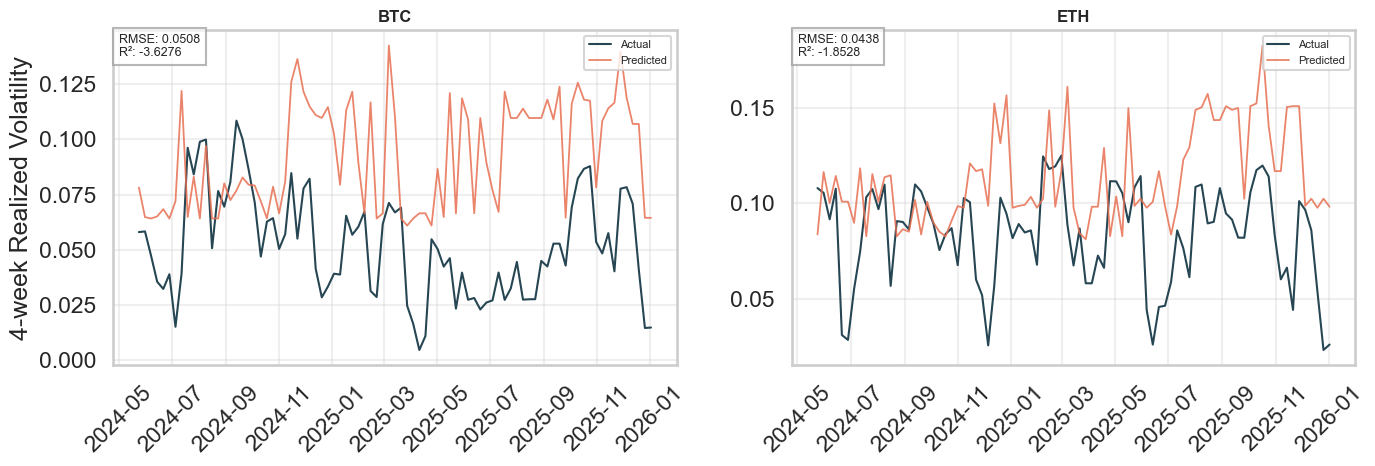

Saved figure to: C:\Users\jayas\Downloads\EC4211 project\output\figures\xgboost_predicted_vs_actual.png


In [13]:
# Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for idx, asset in enumerate(["BTC", "ETH"]):
    preds = model_results[asset]["test_predictions"]
    metrics = model_results[asset]["metrics"]
    ax = axes[idx]

    ax.plot(preds.index, preds["actual"], label="Actual", color="#264653", lw=1.5)
    ax.plot(preds.index, preds["predicted"], label="Predicted", color="#e76f51", lw=1.3, alpha=0.85)
    ax.set_title(f"{asset}", fontweight="bold", fontsize=12)
    ax.set_ylabel("4-week Realized Volatility" if idx == 0 else "")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)
    ax.text(
        0.01,
        0.99,
        f"RMSE: {metrics['rmse']:.4f}\nR²: {metrics['r2']:.4f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        bbox=dict(facecolor="white", edgecolor="#999999", alpha=0.7),
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(PREDICTED_VS_ACTUAL_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", PREDICTED_VS_ACTUAL_FIG_PATH)

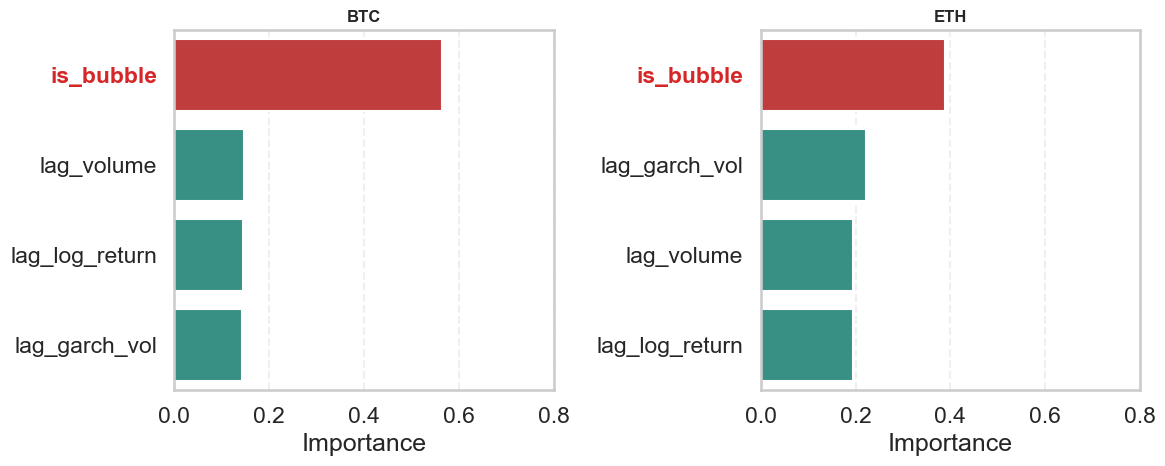

,is_bubble,lag_garch_vol,lag_log_return,lag_volume
BTC,0.564005,0.143286,0.144763,0.147945
ETH,0.389162,0.221288,0.194380,0.195170


Saved figure to: C:\Users\jayas\Downloads\EC4211 project\output\figures\xgboost_feature_importance.png
Saved table to: C:\Users\jayas\Downloads\EC4211 project\output\tables\xgboost_feature_importance.csv


In [14]:
# Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

for idx, asset in enumerate(["BTC", "ETH"]):
    importances = model_results[asset]["feature_importance"]
    ax = axes[idx]
    colors = ["#d62728" if feature == "is_bubble" else "#2a9d8f" for feature in importances.index]

    sns.barplot(
        x=importances.values,
        y=importances.index,
        orient="h",
        ax=ax,
        palette=colors,
        hue=importances.index,
        legend=False,
    )
    ax.set_xlim(0.0, 0.8)
    ax.set_xticks(np.arange(0.0, 0.9, 0.2))

    for label in ax.get_yticklabels():
        if label.get_text() == "is_bubble":
            label.set_color("#d62728")
            label.set_weight("bold")

    ax.set_title(f"{asset}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig(FEATURE_IMPORTANCE_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

feature_importance_table = pd.DataFrame({asset: model_results[asset]["feature_importance"] for asset in ASSETS}).T
feature_importance_table = feature_importance_table[["is_bubble", "lag_garch_vol", "lag_log_return", "lag_volume"]].sort_index()
display(feature_importance_table)
feature_importance_table.to_csv(FEATURE_IMPORTANCE_TABLE_PATH)

print("Saved figure to:", FEATURE_IMPORTANCE_FIG_PATH)
print("Saved table to:", FEATURE_IMPORTANCE_TABLE_PATH)

## 6. Interpretation for the Research Proposal

This notebook strengthens the **Modelling & Robustness** section in three ways:

1. **Bubble-aware forecasting**: the model explicitly tests whether volatility behaves differently during teammate-identified GSADF cryptocurrency bubble weeks.
2. **Parametric + machine-learning synthesis**: precomputed GARCH conditional volatility contributes a theory-consistent volatility signal, while XGBoost captures non-linearities and threshold effects.
3. **Leakage-safe validation**: `TimeSeriesSplit` inside `GridSearchCV` preserves chronology during tuning, and all predictors are aligned weekly with one-week lags where required.

When reporting the results, focus on whether:

- `is_bubble` receives meaningful feature importance for BTC and ETH
- `lag_garch_vol` remains one of the strongest predictors
- forecast fit changes materially during the testing period relative to the training period

Those findings support the proposal's argument that bubble regimes are relevant not only for contemporaneous spillovers, but also for **forward-looking cryptocurrency volatility forecasting**.